# Phase 7 - Class-wise Markov analysis

**Goal**: build a separate Markov transition table for each K-means cluster. 
<br> The table should answer: In this fermentation state, what symbol tends to follow this symbol?

## 0. Setup

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_CLEAN_DIR = '../data_clean'
df = pd.read_csv(os.path.join(DATA_CLEAN_DIR, 'all_events_sml.csv'))
df = df.sort_values('t_rel').reset_index(drop=True)
print(f'Loaded {len(df):,} events')
print(f'Clusters: {sorted(df["cluster"].unique())}')

Loaded 4,312 events
Clusters: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## 7.1 Build Markov tables

In [2]:
def build_markov(symbols, cluster_ids, n_clusters, smoothing=1.0):
    """First-order Markov transitions per cluster, with Laplace smoothing."""
    counts = defaultdict(lambda: defaultdict(lambda: defaultdict(float)))
    for i in range(1, len(symbols)):
        c = cluster_ids[i]
        prev_sym = symbols[i-1]
        cur_sym  = symbols[i]
        counts[c][prev_sym][cur_sym] += 1

    sml = ['S', 'M', 'L']
    models = {}
    for c in range(n_clusters):
        table = {s1: {s2: smoothing for s2 in sml} for s1 in sml}
        for s1, d in counts[c].items():
            for s2, n in d.items():
                table[s1][s2] += n
        for s1 in sml:
            total = sum(table[s1].values())
            for s2 in sml:
                table[s1][s2] /= total
        models[c] = table
    return models

In [3]:
# Symbols and cluster IDs aligned per event
# (skip first event since it has no 'previous interval')
symbols = df['sml'].tolist()[1:]
cluster_ids = df['cluster'].values[1:]
n_clusters = int(df['cluster'].max()) + 1

markov_models = build_markov(symbols, cluster_ids, n_clusters, smoothing=1.0)
print(f'Built Markov tables for {n_clusters} clusters')

Built Markov tables for 4 clusters


## 7.2 Print transition tables

In [4]:
label_map = {
    int(c): df[df['cluster']==c]['cluster_label'].iloc[0]
    for c in df['cluster'].unique()
}

for c in sorted(markov_models.keys()):
    print(f'\nCluster {c} ({label_map[c]}):')
    print(f'  curr -> S       M       L')
    for s1 in ['S', 'M', 'L']:
        ps = ' '.join(f'{markov_models[c][s1][s2]:.3f}' for s2 in ['S','M','L'])
        print(f'  {s1}    -> {ps}')


Cluster 0 (baseline):
  curr -> S       M       L
  S    -> 0.323 0.459 0.219
  M    -> 0.098 0.655 0.247
  L    -> 0.090 0.348 0.562

Cluster 1 (after_silence):
  curr -> S       M       L
  S    -> 0.036 0.036 0.929
  M    -> 0.006 0.006 0.988
  L    -> 0.023 0.006 0.971

Cluster 2 (isolated_burst):
  curr -> S       M       L
  S    -> 0.250 0.250 0.500
  M    -> 0.333 0.333 0.333
  L    -> 0.084 0.466 0.450

Cluster 3 (small_burst):
  curr -> S       M       L
  S    -> 0.286 0.143 0.571
  M    -> 0.333 0.333 0.333
  L    -> 0.071 0.480 0.449


## 7.3 Heatmap of all clusters

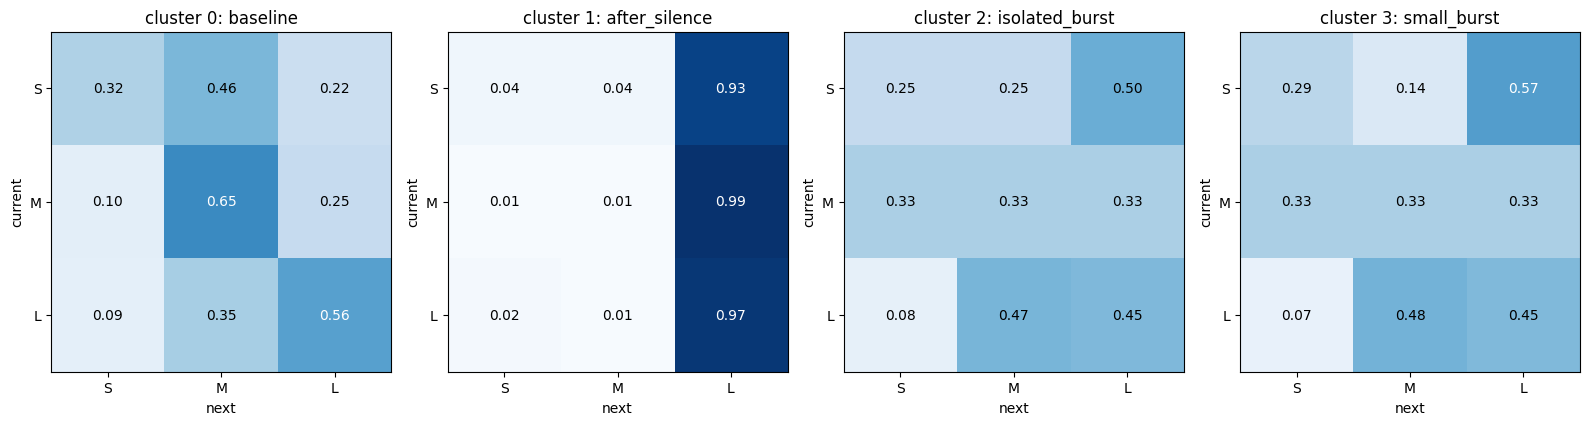

In [5]:
fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4))
if n_clusters == 1:
    axes = [axes]

sml = ['S', 'M', 'L']
for c, ax in zip(sorted(markov_models.keys()), axes):
    M = np.array([[markov_models[c][s1][s2] for s2 in sml] for s1 in sml])
    im = ax.imshow(M, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(sml)
    ax.set_yticks(range(3)); ax.set_yticklabels(sml)
    ax.set_xlabel('next')
    ax.set_ylabel('current')
    ax.set_title(f'cluster {c}: {label_map[c]}')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{M[i,j]:.2f}',
                    ha='center', va='center',
                    color='white' if M[i,j] > 0.5 else 'black')

plt.tight_layout()
plt.savefig('../outputs/plots/20_markov_per_cluster.png', dpi=120)
plt.show()

### Findings
It's interesting to see different pattern in each cluster which makes sense. 
If I were to mention probabilities above 0.4,
- Cluster 0: M-M, L-L, S-M
- Cluster 1: S-L, S-M, L-L
- Cluster 2: S-L, L-M, L-L
- Cluster 3: S-L, L-M, L-L

Since S-S is low for all the cluster, it could mean that "ta-tan" rhythm is quite rare. 

## 7.4 Save Markov models

In [6]:
out_pkl = os.path.join(DATA_CLEAN_DIR, 'markov_models.pkl')
with open(out_pkl, 'wb') as f:
    pickle.dump({
        'markov_models': markov_models,
        'label_map':     label_map,
        'n_clusters':    n_clusters,
        'sml_symbols':   ['S', 'M', 'L'],
    }, f)
print(f'Saved: {out_pkl}')

Saved: ../data_clean/markov_models.pkl
